# 🌊 BinWaves North Carolina (Reconstrction)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
> - `Kp_coefficients.nc` file obtained with the `Propagation Notebook`.
> 
>
> **Outputs:**
> 
> 

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs the **library of pre-run cases** for all **monochromatic wave systems**.

##### Requirements:

- A **bathymetry** file placed in the `inputs/` folder, in the correct format.

If you don't have a specific bathymetry file for your study area, you can:

- **Download GEBCO bathymetry data** (~400 m resolution):  [https://download.gebco.net/](https://download.gebco.net/)


</details>

---

<details open>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **Satellite Correction**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import os.path as op
import sys
import xarray as xr
import numpy as np

In [2]:
cawcr_spectrum = xr.open_dataset("inputs/superPoint.nc")
cawcr_spectrum

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 405963, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
  * freq       (freq) float32 116B 0.035 0.0385 0.04235 ... 0.4171 0.4589 0.5047
  * dir        (dir) float32 96B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    station    int64 8B ...
Data variables:
    efth       (time, freq, dir) float64 2GB ...
    Depth      (time, dir) float64 78MB ...
    Wspeed     (time, dir) float64 78MB ...
    Wdir       (time, dir) float64 78MB ...
    longitude  float64 8B ...
    latitude   float64 8B ...

In [3]:
import xarray as xr

# Load all the gridded kps and reproject
kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
kp_coeffs

<xarray.Dataset> Size: 2GB
Dimensions:   (case_num: 696, site: 605, freq: 29, dir: 24)
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * site      (site) int64 5kB 1 2 3 4 5 6 7 8 ... 599 600 601 602 603 604 605
  * freq      (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4171 0.4589 0.5047
  * dir       (dir) float64 192B 3.928 18.93 33.93 48.93 ... 318.9 333.9 348.9
    lat       float64 8B ...
    lon       float64 8B ...
    coord_x   (site) float64 5kB ...
    coord_y   (site) float64 5kB ...
Data variables:
    kps       (case_num, site, freq, dir) float64 2GB ...

In [4]:
import pandas as pd
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra

offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    CAWCR_spectrum=cawcr_spectrum,
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    fixed_direction=True # True if efth is already in degrees(no radians) and cawcr direction for wavespectra  already corrected (from -> to)'
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 696, time: 405963)> Size: 2GB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.50572768e-19],
       ...,
       [0.00000000e+00, 6.01560369e-27, 2.46071238e-22, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.80762353e-27, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 7.06916985e-25, 8.06842138e-23, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(696, 405963))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station   int64 8B 4469

In [5]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

time_to_reconstruct = "2022-02-20"

# Reconstruct spectra
reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=time_to_reconstruct),
    kp_coeffs=kp_coeffs,
    num_workers=15,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 81MB
Dimensions:  (site: 605, freq: 29, dir: 24, time: 24)
Coordinates:
  * site     (site) int64 5kB 1 2 3 4 5 6 7 8 ... 599 600 601 602 603 604 605
  * freq     (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4171 0.4589 0.5047
  * dir      (dir) float64 192B 3.928 18.93 33.93 48.93 ... 318.9 333.9 348.9
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    coord_x  (site) float64 5kB -77.78 -77.67 -77.56 ... -77.72 -77.76 -78.02
    coord_y  (site) float64 5kB 33.44 33.51 33.58 33.66 ... 34.14 33.44 33.72
  * time     (time) datetime64[ns] 192B 2022-02-20 ... 2022-02-20T23:00:00.00...
    station  int64 8B 4469
Data variables:
    kps      (time, site, freq, dir) float64 81MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

(<Figure size 1500x600 with 2 Axes>,
 <GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

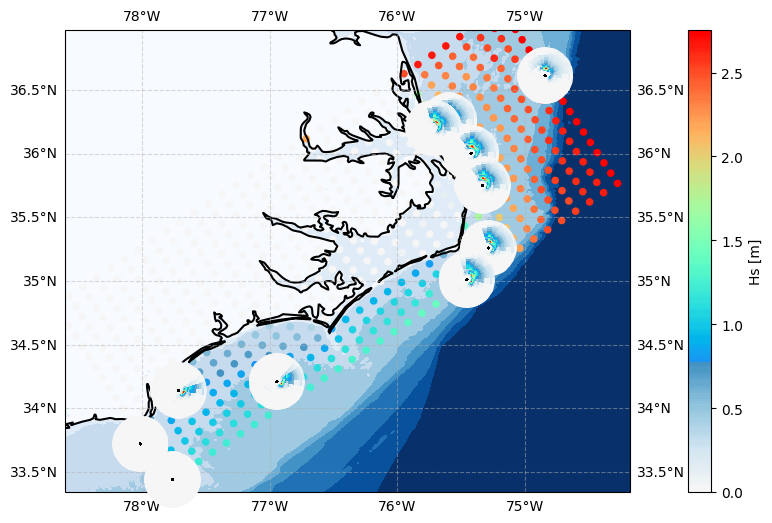

In [6]:
import xarray as xr
from utils.plotting import plot_spectrum_in_coastline

time_to_plot = "2022-02-20 12:00"

# Plot the spectrum along the coastline
bathy = xr.open_dataset("outputs/cropped_bathy_North_Carolina.nc").elevation.T
plot_spectrum_in_coastline(
    bathy=-bathy,
    reconstructed_onshore_spectra=reconstructed_onshore_spectra.rename({"kps": "kp"}),
    reconstruction_kps=kp_coeffs,
    offshore_spectra=offshore_spectra,
    time_to_plot=time_to_plot,
    sites_for_spectrum=list(range(-11, 0))

)